# Emotion analysis of cultural texts using BERT and GPT models

The project compares the quality of emotion classification on the **GoEmotions** dataset for two families of models:

- **BERT-type models (fine-tuning):** DistilBERT, RoBERTa, ALBERT — trained as 28-class classifiers.
- **GPT-type models (zero-shot):** Llama 3 and Gemma 2 — they answer with free text, which we map onto the same 28 labels, so that they feed into the same metrics.

The problem is reduced to **single-label classification (28 classes = 27 emotions + `neutral`)**: from GoEmotions we keep only the examples with exactly one emotion.

---

## How to run

**Environment:** Google Colab → `Runtime` → `Change runtime type` → **GPU (T4)**.

**Control flags:**
- `MODELS_DIR` — directory for the saved models/results
- `FORCE_RETRAIN` — `False`: if the model/results are already saved on disk, they will be loaded instead of being recomputed; `True`: forces retraining
- `GPT_EVAL_N` — number of test examples evaluated by the GPT models (zero-shot is slow). `None` = the whole test set

## Environment configuration

Installing the dependencies, importing the libraries, setting the random seed and the control flags.
The BERT models are public, and the GPT models are loaded from **ungated** copies (`unsloth/...`).

In [ ]:
# Installing the dependencies.
# - sentencepiece: required by the tokenizers
# - bitsandbytes + accelerate: loading the GPT models in 4-bit on the GPU
# - statsmodels: McNemar's test (comparing the significance of the differences between models)
!pip install -q -U transformers datasets evaluate accelerate bitsandbytes sentencepiece scikit-learn seaborn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [2]:
import os
import gc
import re
import json
import time
import random
from itertools import combinations

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForCausalLM,
    Trainer,
    TrainingArguments,
    set_seed,
)
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
    accuracy_score,
    f1_score,
)

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Urządzenie: cpu


In [3]:
FORCE_RETRAIN = False   # True => train/compute from scratch, ignoring the saved models and results
GPT_EVAL_N = 1000       # number of test examples for the GPT models; None => the whole test set

# --- Directory for the saved models and results ---
# On Colab - Google Drive
# Locally (outside Colab) we use a regular folder in the current directory.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    MODELS_DIR = "/content/drive/MyDrive/ssn_emotions_models"
except Exception:
    MODELS_DIR = "./ssn_emotions_models"

RESULTS_DIR = os.path.join(MODELS_DIR, "results")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Models/results directory:", MODELS_DIR)

Mounted at /content/drive
Katalog modeli/wyników: /content/drive/MyDrive/ssn_emotions_models


## Loading and preparing the data (GoEmotions)

We load the `simplified` configuration of the GoEmotions dataset (43 410 / 5 426 / 5 427 examples: train / validation / test).
GoEmotions is multi-label, which is why we reduce it to a single-label problem:

1. we keep only the examples with exactly one emotion,
2. we extract that emotion into the `label` field.

In [4]:
dataset = load_dataset("google-research-datasets/go_emotions", "simplified")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/9.40k [00:00<?, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [5]:
dataset = dataset.filter(lambda d: len(d["labels"]) == 1)
dataset = dataset.map(lambda d: {"label": d["labels"][0]})

print("Split sizes after filtering:")
print({split: len(dataset[split]) for split in dataset})

Filter:   0%|          | 0/43410 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5426 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5427 [00:00<?, ? examples/s]

Map:   0%|          | 0/36308 [00:00<?, ? examples/s]

Map:   0%|          | 0/4548 [00:00<?, ? examples/s]

Map:   0%|          | 0/4590 [00:00<?, ? examples/s]

Rozmiary splitów po filtracji:
{'train': 36308, 'validation': 4548, 'test': 4590}


In [6]:
print(dataset["train"][0:10])

{'text': ["My favourite food is anything I didn't have to cook myself.", 'Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead', 'WHY THE FUCK IS BAYLESS ISOING', 'To make her feel threatened', 'Dirty Southern Wankers', "OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe PlAyOfFs! Dumbass Broncos fans circa December 2015.", 'Yes I heard abt the f bombs! That has to be why. Thanks for your reply:) until then hubby and I will anxiously wait 😝', 'Damn youtube and outrage drama is super lucrative for reddit', 'It might be linked to the trust factor of your friend.', 'Demographics? I don’t know anybody under 35 who has cable tv.'], 'labels': [[27], [27], [2], [14], [3], [26], [15], [0], [27], [6]], 'id': ['eebbqej', 'ed00q6i', 'eezlygj', 'ed7ypvh', 'ed0bdzj', 'edvnz26', 'ee3b6wu', 'ed8wbdn', 'eczgv1o', 'eel6g5h'], 'label': [27, 27, 2, 14, 3, 26, 15, 0, 27, 6]}


In [7]:
# The full list of the 28 GoEmotions labels
emotions = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral",
]
NUM_LABELS = len(emotions)
id2label = {i: e for i, e in enumerate(emotions)}
label2id = {e: i for i, e in enumerate(emotions)}
print("Number of classes:", NUM_LABELS)

Liczba klas: 28


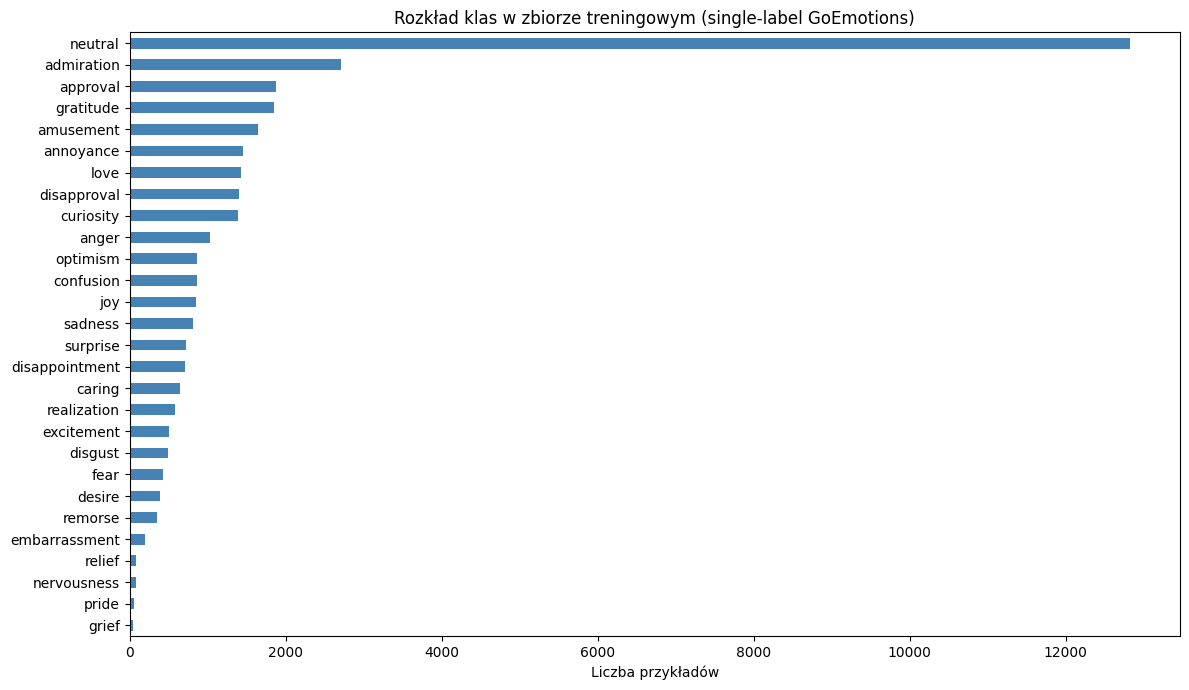

,count
neutral,12823
admiration,2710
approval,1873
gratitude,1857
amusement,1652
annoyance,1451
love,1427
disapproval,1402
curiosity,1389
anger,1025


In [8]:
train_labels = np.array(dataset["train"]["label"])
counts = pd.Series(train_labels).value_counts().sort_index()
counts.index = [id2label[i] for i in counts.index]

plt.figure(figsize=(12, 7))
counts.sort_values().plot(kind="barh", color="steelblue")
plt.title("Class distribution in the training set (single-label GoEmotions)")
plt.xlabel("Number of examples")
plt.tight_layout()
plt.show()

counts.sort_values(ascending=False)

## Shared metrics module and helper functions

So that the results of the BERT and GPT models are fully comparable, we define here a single set of functions computing the metrics.


We also define:
- `compute_metrics` — used by `Trainer` during BERT training (with `zero_division=0`, because rare classes may end up with no predictions at all),
- mappings of emotions onto sentiment groups (positive/negative/ambiguous/neutral) for the hierarchical evaluation,
- the `save_results` / `load_results` functions for saving (or loading) the results to/from disk

In [9]:
# Grouping the GoEmotions emotions by sentiment
SENTIMENT_GROUPS = {
    "positive": ["admiration", "amusement", "approval", "caring", "desire", "excitement",
                 "gratitude", "joy", "love", "optimism", "pride", "relief"],
    "negative": ["anger", "annoyance", "disappointment", "disapproval", "disgust",
                 "embarrassment", "fear", "grief", "nervousness", "remorse", "sadness"],
    "ambiguous": ["confusion", "curiosity", "realization", "surprise"],
    "neutral": ["neutral"],
}
emotion_to_sentiment = {e: g for g, es in SENTIMENT_GROUPS.items() for e in es}
sentiment_names = list(SENTIMENT_GROUPS.keys())
sentiment_to_id = {s: i for i, s in enumerate(sentiment_names)}

# Vector mapping an emotion id (0..27) -> a sentiment group id (0..3).
emo_id_to_sent_id = np.array(
    [sentiment_to_id[emotion_to_sentiment[id2label[i]]] for i in range(NUM_LABELS)]
)

In [ ]:
def basic_metrics(y_true, y_pred):
    """Basic classification metrics shared by all models."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
    }


def compute_metrics(eval_pred):
    """Metrics computed by Trainer during BERT training (prediction = argmax of the logits)."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
    }


def top_k_accuracy(y_true, proba, k=3):
    """Whether the true class is among the k most probable ones. Requires a probability distribution (BERT only)."""
    if proba is None:
        return None
    topk = np.argsort(proba, axis=1)[:, -k:]
    return float(np.mean([yt in row for yt, row in zip(np.asarray(y_true), topk)]))


In [11]:
# Serialising the results to disk
def save_results(name, res):
    path = os.path.join(RESULTS_DIR, f"{name}.npz")
    np.savez_compressed(
        path,
        true=np.asarray(res["true"]),
        pred=np.asarray(res["pred"]),
        proba=res["proba"] if res["proba"] is not None else np.array([]),
        metrics=json.dumps(res["metrics"]),
        extra=json.dumps(res.get("extra", {})),
    )


def load_results(name):
    path = os.path.join(RESULTS_DIR, f"{name}.npz")
    if not os.path.exists(path):
        return None
    d = np.load(path, allow_pickle=True)
    proba = d["proba"]
    return {
        "true": d["true"],
        "pred": d["pred"],
        "proba": None if proba.size == 0 else proba,
        "metrics": json.loads(str(d["metrics"])),
        "extra": json.loads(str(d["extra"])),
    }


# Global dictionary with the results of all models:
#   results[name] = {"true", "pred", "proba" (or None), "metrics", "extra"}
results = {}

## BERT models (fine-tuning)

We train three 28-class classifiers on the **full** training set:

| Key | Model |
|------|-------|
| `distilbert` | `distilbert-base-uncased` |
| `roberta` | `roberta-base` |
| `albert`  | `albert-base-v2` |

The `load_or_train_bert` function:
- if the model is already saved in `MODELS_DIR` and `FORCE_RETRAIN=False` → loads it from disk and only runs prediction on the test set,
- otherwise → trains it (3 epochs, lr 2e-5, `load_best_model_at_end` by macro F1), saves the model and the tokenizer to disk, and then predicts.

For each model we save into `results`: the true labels, the predictions (`argmax`), the probability distribution (`softmax`) and the prediction latency.

In [ ]:
BERT_MODELS = {
    "distilbert": "distilbert-base-uncased",
    "RoBERTa": "roberta-base",
    "ALBERT": "albert-base-v2"
}
num_labels = 28
results = {}

In [14]:
def load_or_train_bert(name, model_id):
    """Trains (or loads from disk) a BERT classifier and returns the predictions on the test set
    in a uniform format compatible with the `results` dictionary."""
    out_dir = os.path.join(MODELS_DIR, name)
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    # Tokenising the whole dataset
    def tokenize_function(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

    tokenized = dataset.map(tokenize_function, batched=True)

    saved = os.path.isdir(out_dir) and os.path.exists(os.path.join(out_dir, "config.json"))

    if saved and not FORCE_RETRAIN:
        print(f"[{name}] Loading the saved model from: {out_dir}")
        model = AutoModelForSequenceClassification.from_pretrained(out_dir)
    else:
        print(f"[{name}] Training the model: {model_id}")
        model = AutoModelForSequenceClassification.from_pretrained(
            model_id, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id
        )
        training_args = TrainingArguments(
            output_dir=os.path.join(out_dir, "checkpoints"),
            eval_strategy="epoch",
            save_strategy="epoch",
            learning_rate=2e-5,
            per_device_train_batch_size=16,
            per_device_eval_batch_size=32,
            num_train_epochs=3,
            weight_decay=0.01,
            logging_steps=100,
            fp16=(device == "cuda"),
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            save_total_limit=1,
            report_to="none",
        )
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=tokenized["train"],
            eval_dataset=tokenized["validation"],
            compute_metrics=compute_metrics,
        )
        trainer.train()
        # Saving the best model and the tokenizer to disk
        model.save_pretrained(out_dir)
        tokenizer.save_pretrained(out_dir)
        print(f"[{name}] Saved the model in: {out_dir}")

    # Prediction on the test set + latency measurement (time per single example).
    pred_args = TrainingArguments(
        output_dir=os.path.join(out_dir, "tmp_predict"),
        per_device_eval_batch_size=32,
        fp16=(device == "cuda"),
        report_to="none",
    )
    predictor = Trainer(model=model, args=pred_args)
    t0 = time.time()
    pred_out = predictor.predict(tokenized["test"])
    latency = (time.time() - t0) / len(tokenized["test"])

    logits = torch.tensor(pred_out.predictions)
    proba = torch.softmax(logits, dim=-1).numpy()
    preds = proba.argmax(axis=-1)
    y_true = np.array(tokenized["test"]["label"])

    res = {
        "true": y_true,
        "pred": preds,
        "proba": proba,
        "metrics": basic_metrics(y_true, preds),
        "extra": {"latency_per_sample_s": latency, "type": "bert"},
    }

    del model, predictor
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    return res

In [15]:
# Loop over the BERT models. With FORCE_RETRAIN=False we first try to load ready results from disk.
for name, model_id in BERT_MODELS.items():
    cached = None if FORCE_RETRAIN else load_results(name)
    if cached is not None:
        print(f"[{name}] Loaded the saved results from disk.")
        results[name] = cached
    else:
        results[name] = load_or_train_bert(name, model_id)
        save_results(name, results[name])
    print(f"[{name}] metrics:", results[name]["metrics"])

[distilbert] Wczytano zapisane wyniki z dysku.
[distilbert] metryki: {'accuracy': 0.6296296296296297, 'f1_macro': 0.4835166229688826, 'f1_weighted': 0.6175923750342759, 'cohen_kappa': 0.5609981606706225}
[RoBERTa] Wczytano zapisane wyniki z dysku.
[RoBERTa] metryki: {'accuracy': 0.6198257080610022, 'f1_macro': 0.52283685629232, 'f1_weighted': 0.6132012676608888, 'cohen_kappa': 0.5555238257331314}
[ALBERT] Wczytano zapisane wyniki z dysku.
[ALBERT] metryki: {'accuracy': 0.6355119825708061, 'f1_macro': 0.4909133368305634, 'f1_weighted': 0.6186852944133778, 'cohen_kappa': 0.5585268279748978}


## GPT models (zero-shot)

The generative models are not trained - in the prompt they are given the list of the 28 allowed labels and are supposed to return exactly one of them. We map the answer onto a class id with the `parse_emotion` function, so that the results feed into the same metrics as BERT.

Models (ungated 4-bit copies, loaded without an HF token):

| Key | Model |
|------|-------|
| `llama3` | `unsloth/llama-3-8b-Instruct-bnb-4bit` |
| `gemma2` | `unsloth/gemma-2-9b-it-bnb-4bit` |

Notes:
- zero-shot on the whole test set is slow — `GPT_EVAL_N` limits the number of examples (500 by default),
- if the GPU runs out of memory, Gemma can be swapped for `unsloth/gemma-2-2b-it-bnb-4bit`,
- the GPT models do not return a probability distribution, hence `proba=None` (the top-k / ECE metrics will be N/A for them),
- we also save `no_match_rate` — the share of answers that could not be mapped onto any label (fallback = `neutral`).

> We evaluate the BERT models on the full test set and the GPT ones on a `GPT_EVAL_N` subset (the first N test examples). The metrics of each model are computed on its own data; direct comparisons are narrowed down to the common subset.

In [16]:
GPT_MODELS = {
    "llama3": "unsloth/llama-3-8b-Instruct-bnb-4bit",
    "gemma2": "unsloth/gemma-2-9b-it-bnb-4bit",
}

# Zero-shot instruction: the full list of the 28 labels + the requirement to return exactly one of them.
EMOTION_LIST_STR = ", ".join(emotions)
PROMPT_TEMPLATE = (
    "You are an emotion classification system.\n"
    "Classify the single dominant emotion expressed in the text below.\n"
    "Answer with EXACTLY ONE label from this list and nothing else:\n"
    f"{EMOTION_LIST_STR}.\n\n"
    'Text: "{text}"\n'
    "Emotion:"
)


def parse_emotion(generated_text):
    """Maps the free-form answer of the model onto the id of one of the 28 emotions.
    Returns (label_id, matched); matched=False means no hit -> fallback = neutral."""
    text = generated_text.lower().strip()
    # Whole-word match on an emotion name (the first one found).
    for i, emo in enumerate(emotions):
        if re.search(rf"\b{re.escape(emo)}\b", text):
            return i, True
    return label2id["neutral"], False

In [17]:
@torch.no_grad()
def classify_with_gpt(model_id, texts):
    """Zero-shot classification of a list of texts. Returns (predictions, number_of_misses, latency_per_example)."""
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="auto",
        torch_dtype=torch.float16,
        attn_implementation="eager",
    )
    model.eval()
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    preds, n_unmatched = [], 0
    t0 = time.time()
    for text in texts:
        prompt = PROMPT_TEMPLATE.format(text=text)
        messages = [{"role": "user", "content": prompt}]

        # Applying the chat template to obtain clean formatted text
        prompt_text = tokenizer.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=False
        )
        # Standard tokenisation - returns a BatchEncoding
        inputs = tokenizer(prompt_text, return_tensors="pt").to(model.device)

        # Generation with dictionary unpacking (**inputs)
        out = model.generate(
            **inputs,
            max_new_tokens=8,          # enough for a single label
            do_sample=False,           # deterministic (greedy) for reproducibility
            pad_token_id=tokenizer.pad_token_id,
        )

        # Correct reference to the input length via inputs["input_ids"]
        input_length = inputs["input_ids"].shape[-1]
        generated = tokenizer.decode(out[0][input_length:], skip_special_tokens=True)

        label_id, matched = parse_emotion(generated)
        preds.append(label_id)
        if not matched:
            n_unmatched += 1
    latency = (time.time() - t0) / max(len(texts), 1)

    del model
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()
    return np.array(preds), n_unmatched, latency

In [18]:
# We take the first GPT_EVAL_N test examples (or the whole test set when GPT_EVAL_N=None).
GPT_EVAL_N = 1000
test_texts_full = dataset["test"]["text"]
test_labels_full = np.array(dataset["test"]["label"])

n_gpt = len(test_texts_full) if GPT_EVAL_N is None else min(GPT_EVAL_N, len(test_texts_full))
gpt_idx = np.arange(n_gpt)
gpt_texts = [test_texts_full[i] for i in gpt_idx]
gpt_true = test_labels_full[gpt_idx]
print(f"Number of examples to be evaluated by the GPT models: {n_gpt}")

for name, model_id in GPT_MODELS.items():
    cached = None if FORCE_RETRAIN else load_results(name)
    if cached is not None:
        print(f"[{name}] Loaded the saved results from disk.")
        results[name] = cached
        continue

    print(f"[{name}] Zero-shot classification of {n_gpt} examples with the model: {model_id}")
    preds, n_unmatched, latency = classify_with_gpt(model_id, gpt_texts)
    results[name] = {
        "true": gpt_true,
        "pred": preds,
        "proba": None,
        "metrics": basic_metrics(gpt_true, preds),
        "extra": {
            "latency_per_sample_s": latency,
            "no_match_rate": n_unmatched / max(n_gpt, 1),
            "type": "gpt",
        },
    }
    save_results(name, results[name])
    print(f"[{name}] metrics:", results[name]["metrics"],
          "| no_match_rate:", round(results[name]["extra"]["no_match_rate"], 4))

Liczba przykładów do oceny przez modele GPT: 1000
[llama3] Wczytano zapisane wyniki z dysku.
[gemma2] Wczytano zapisane wyniki z dysku.


## Metrics and evaluation

All the models (BERT and GPT) feed into the same set of metrics. Each metric has its own description and its own code cell, working in a loop over `results`.

### Summary table

An overview of the basic metrics for all models: **accuracy**, **macro F1** (treats the classes equally), **weighted F1** (weights the classes by their frequency) and **Cohen's Kappa** (agreement corrected for chance). We sort by macro F1.

In [19]:
summary = pd.DataFrame({name: r["metrics"] for name, r in results.items()}).T
summary = summary[["accuracy", "f1_macro", "f1_weighted", "cohen_kappa"]]
summary["type"] = [results[n]["extra"].get("type", "") for n in summary.index]
summary["latency_s/ex"] = [results[n]["extra"].get("latency_per_sample_s", np.nan) for n in summary.index]
summary.sort_values("f1_macro", ascending=False)

,accuracy,f1_macro,f1_weighted,cohen_kappa,type,latency_s/ex
RoBERTa,0.619826,0.522837,0.613201,0.555524,bert,0.001972
ALBERT,0.635512,0.490913,0.618685,0.558527,bert,0.003148
distilbert,0.629630,0.483517,0.617592,0.560998,bert,0.000988
gemma2,0.239000,0.234058,0.242363,0.192105,gpt,1.964067
llama3,0.227000,0.197026,0.202953,0.178831,gpt,1.279792


### Confusion matrix

A 28×28 matrix for each model. Rows = true class, columns = predicted class. The values are row-normalised (the share within a given true class), which makes the reading independent of the class imbalance. A bright diagonal = a good fit; bright cells off the diagonal indicate systematic confusions.

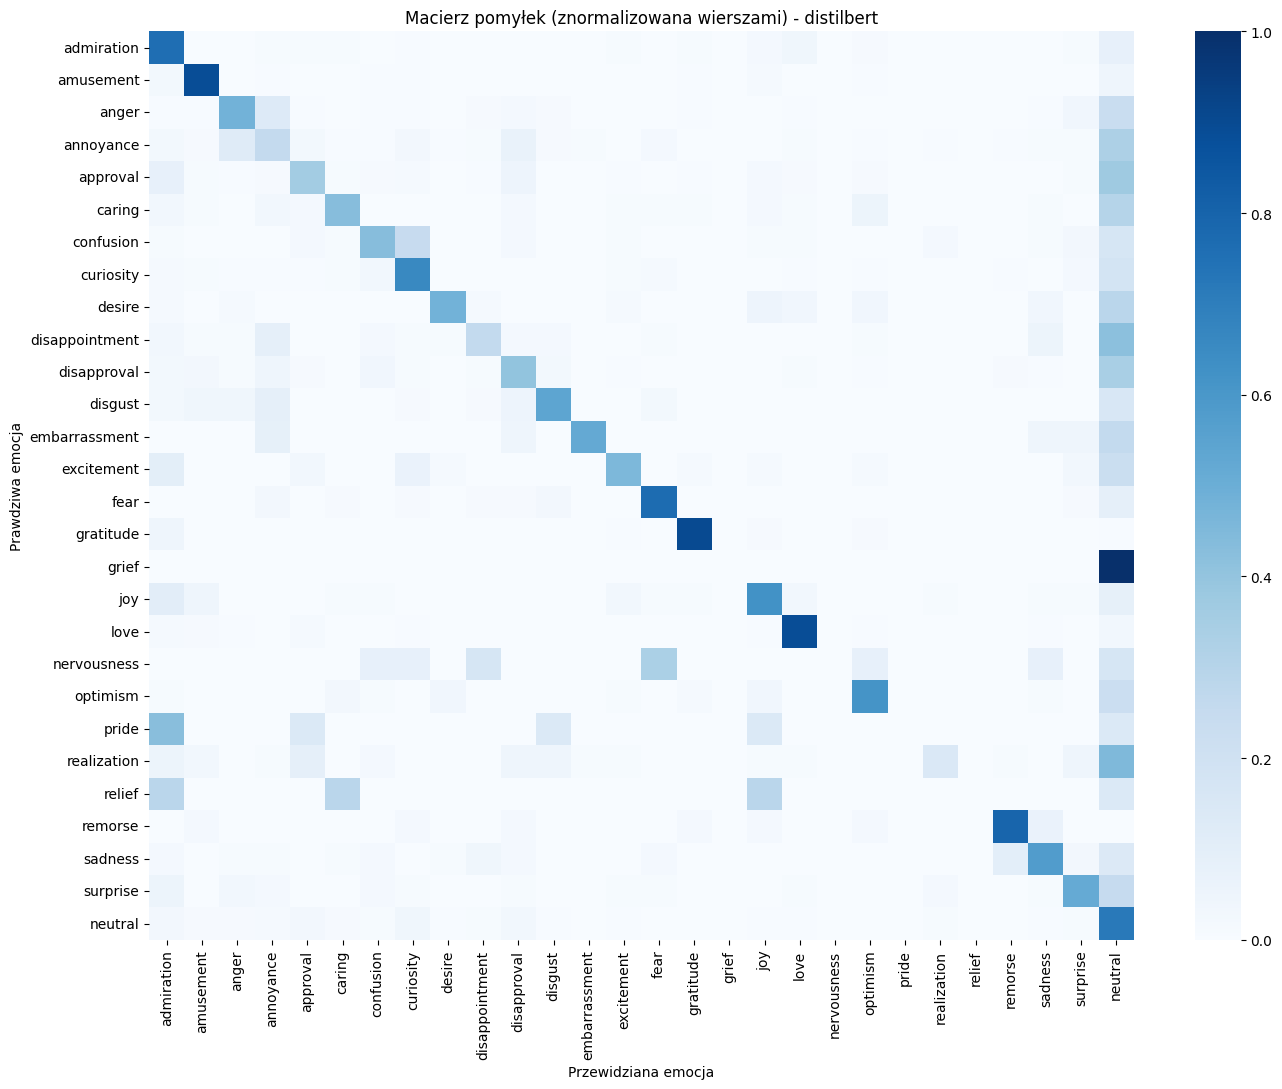

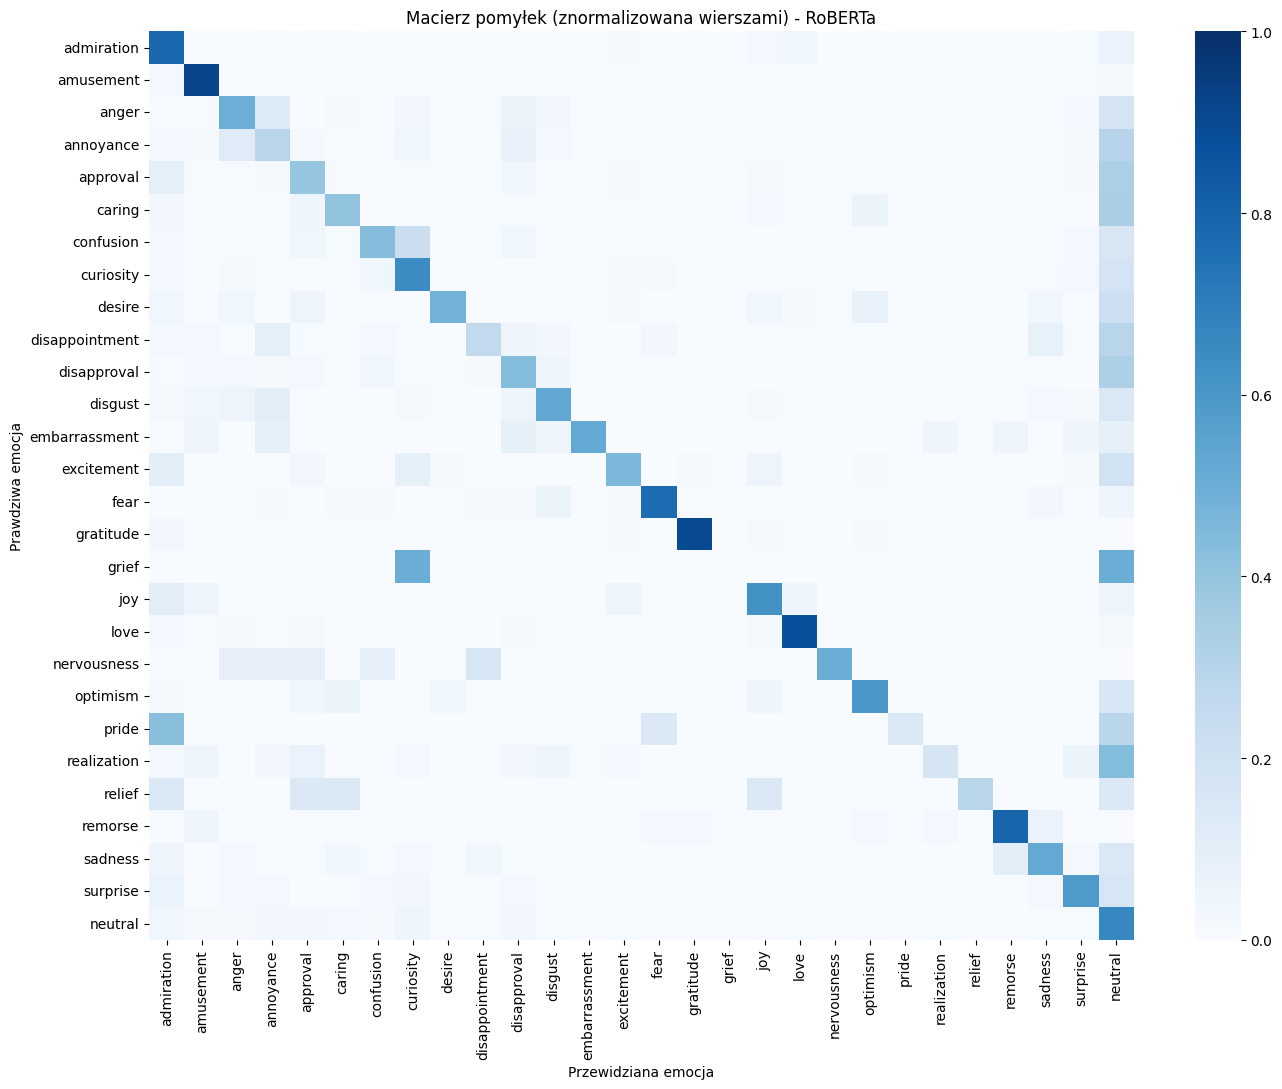

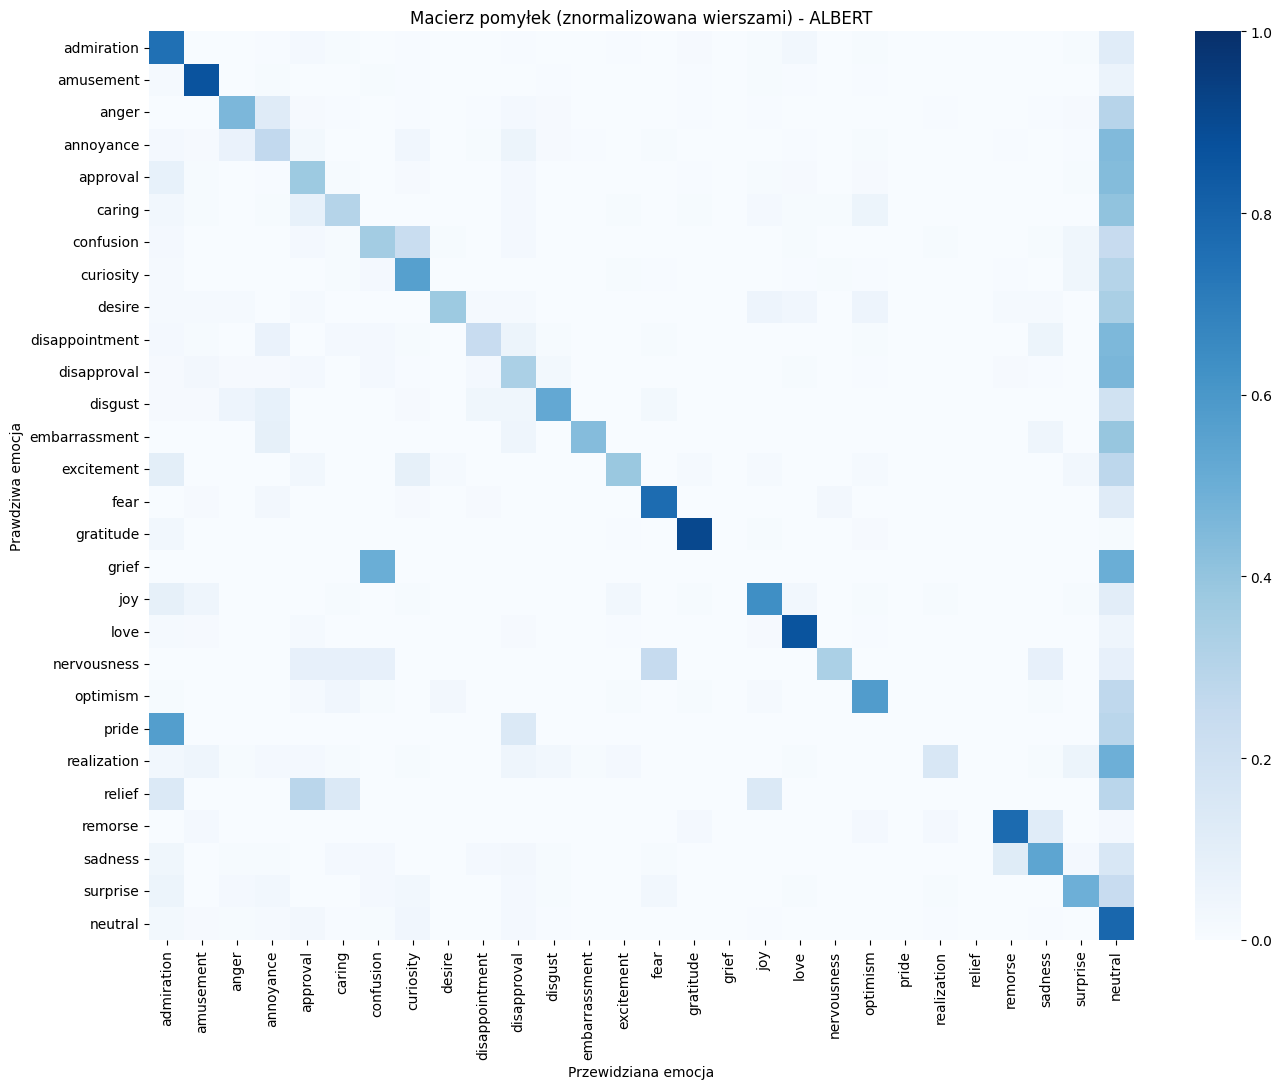

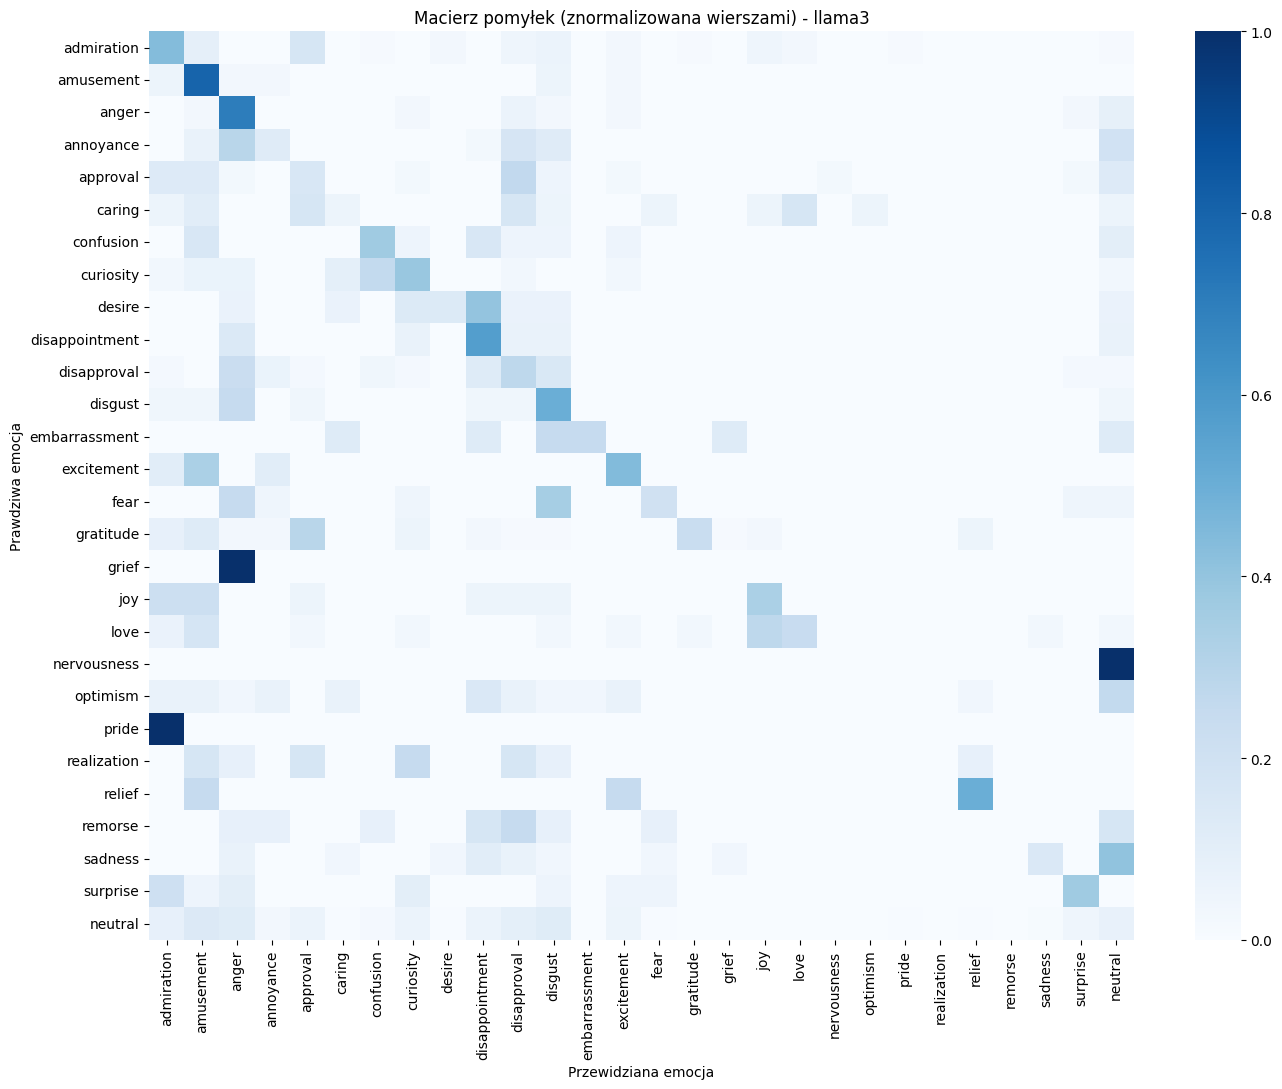

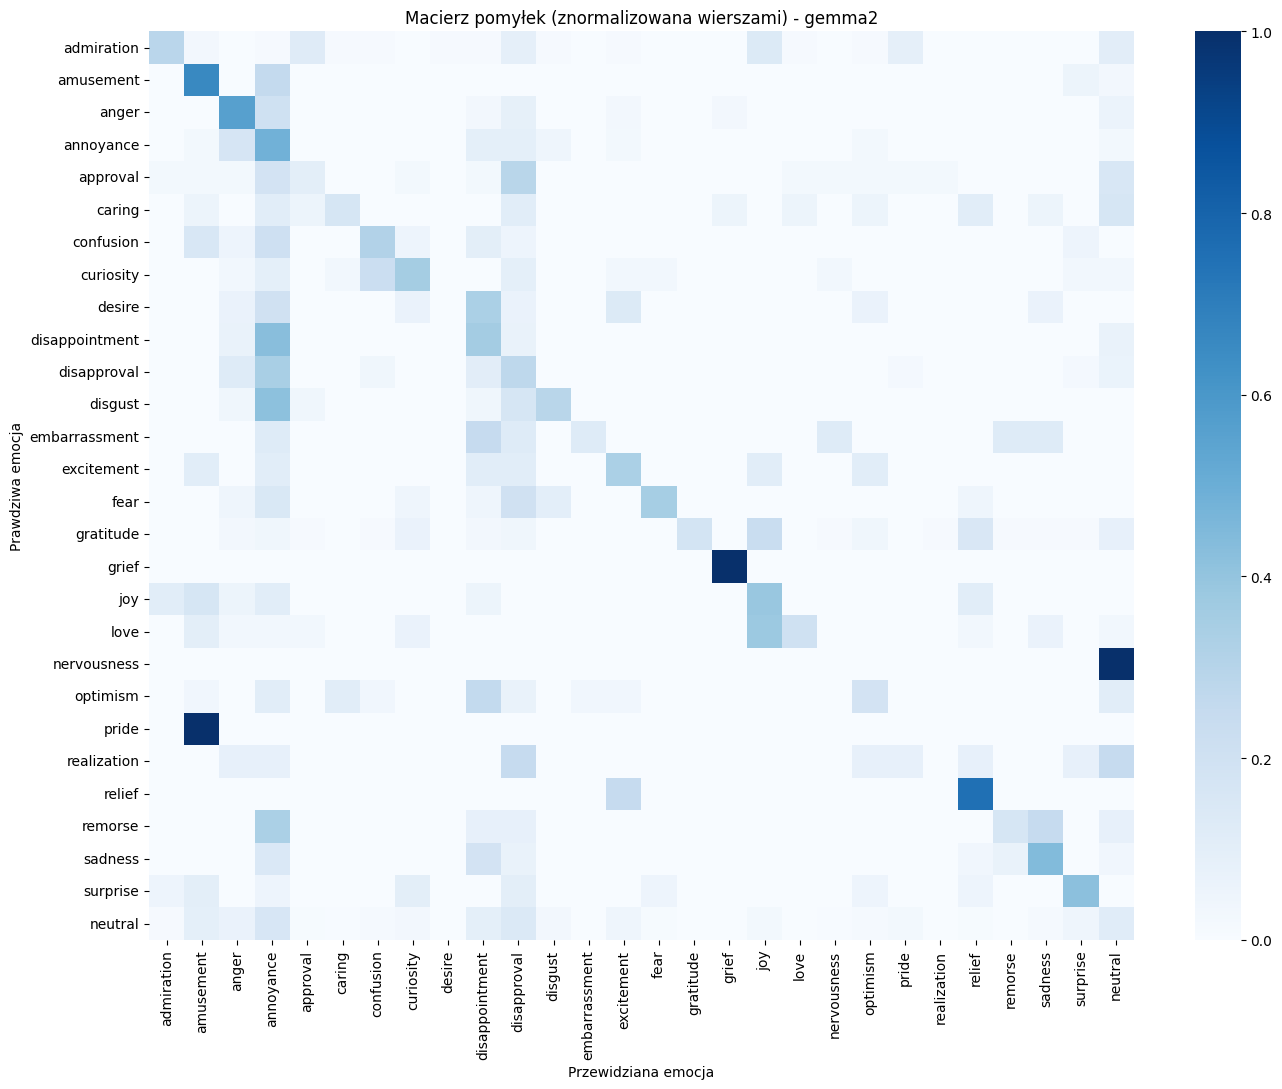

In [20]:
def plot_confusion(name):
    r = results[name]
    cm = confusion_matrix(r["true"], r["pred"], labels=range(NUM_LABELS))
    # Row normalisation (the share within the true class); guard against division by 0.
    cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
    plt.figure(figsize=(14, 11))
    sns.heatmap(cm_norm, cmap="Blues", xticklabels=emotions, yticklabels=emotions, vmin=0, vmax=1)
    plt.title(f"Confusion matrix (row-normalised) - {name}")
    plt.xlabel("Predicted emotion")
    plt.ylabel("True emotion")
    plt.tight_layout()
    plt.show()


for name in results:
    plot_confusion(name)

### F1-score per emotion

A plot of F1 for each of the 28 emotions separately, with the mean (macro F1) marked. It shows which emotions are easy (e.g. `gratitude`, `love`) and which are hard (rare/ambiguous ones, e.g. `grief`, `realization`, `nervousness`). The red line = the macro F1 of the given model.

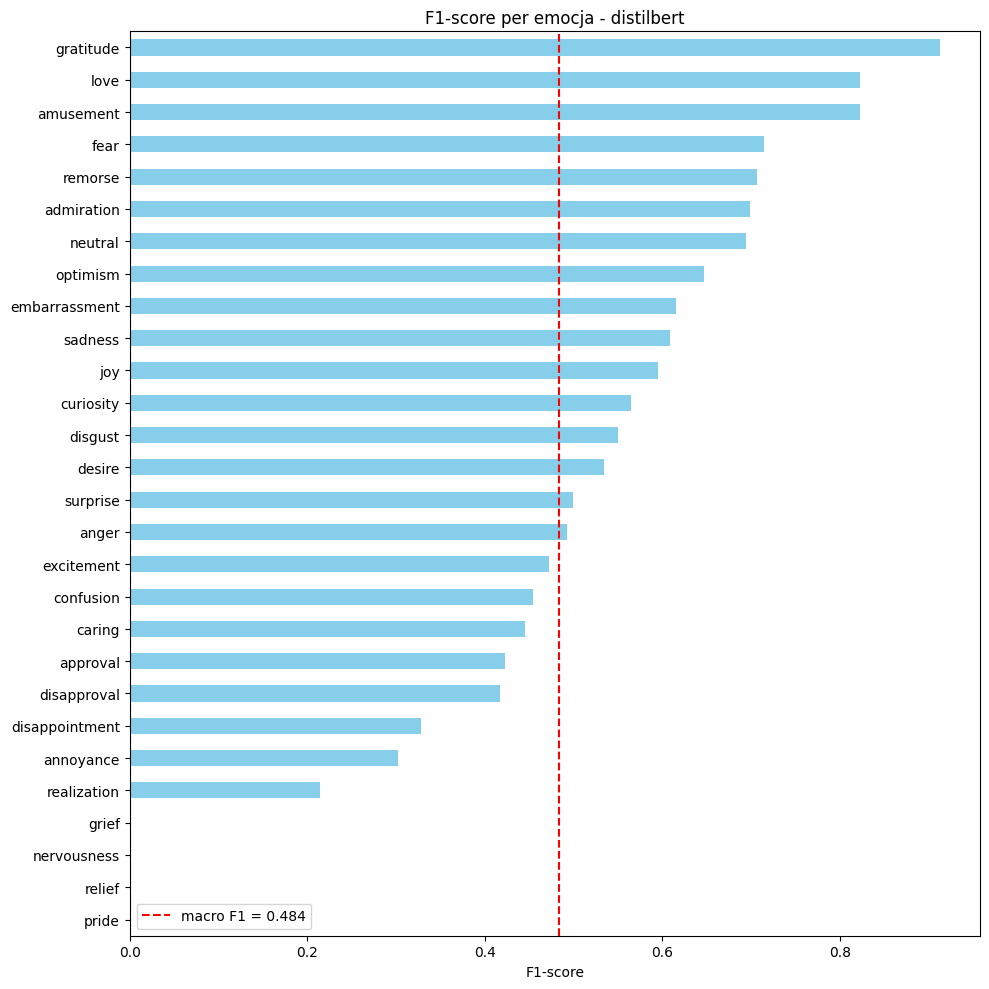

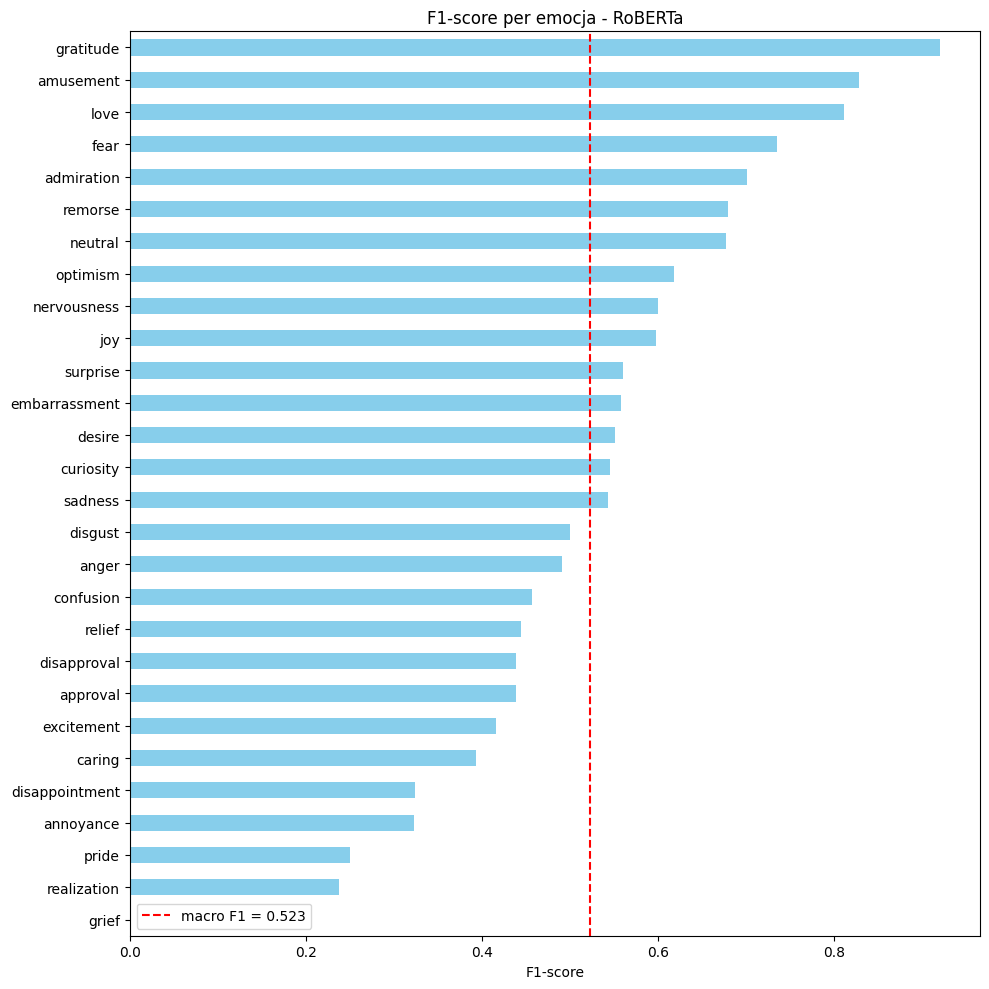

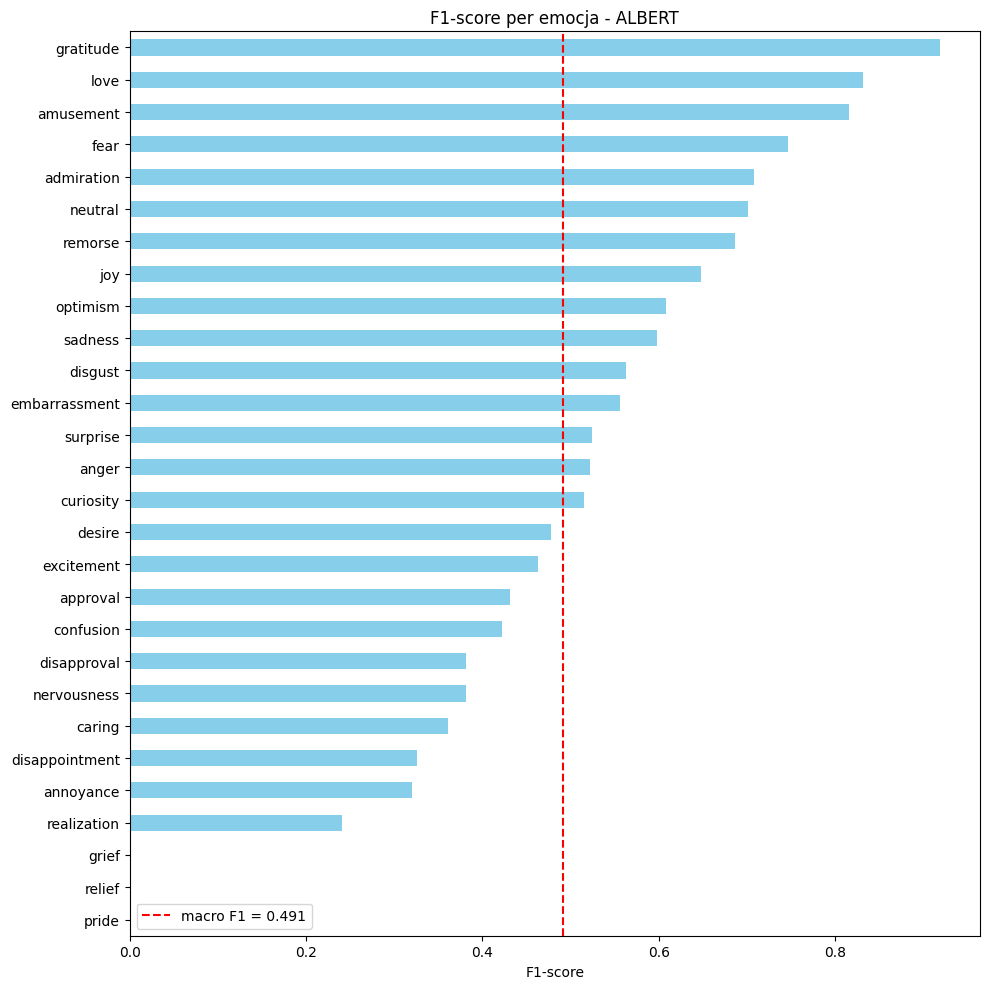

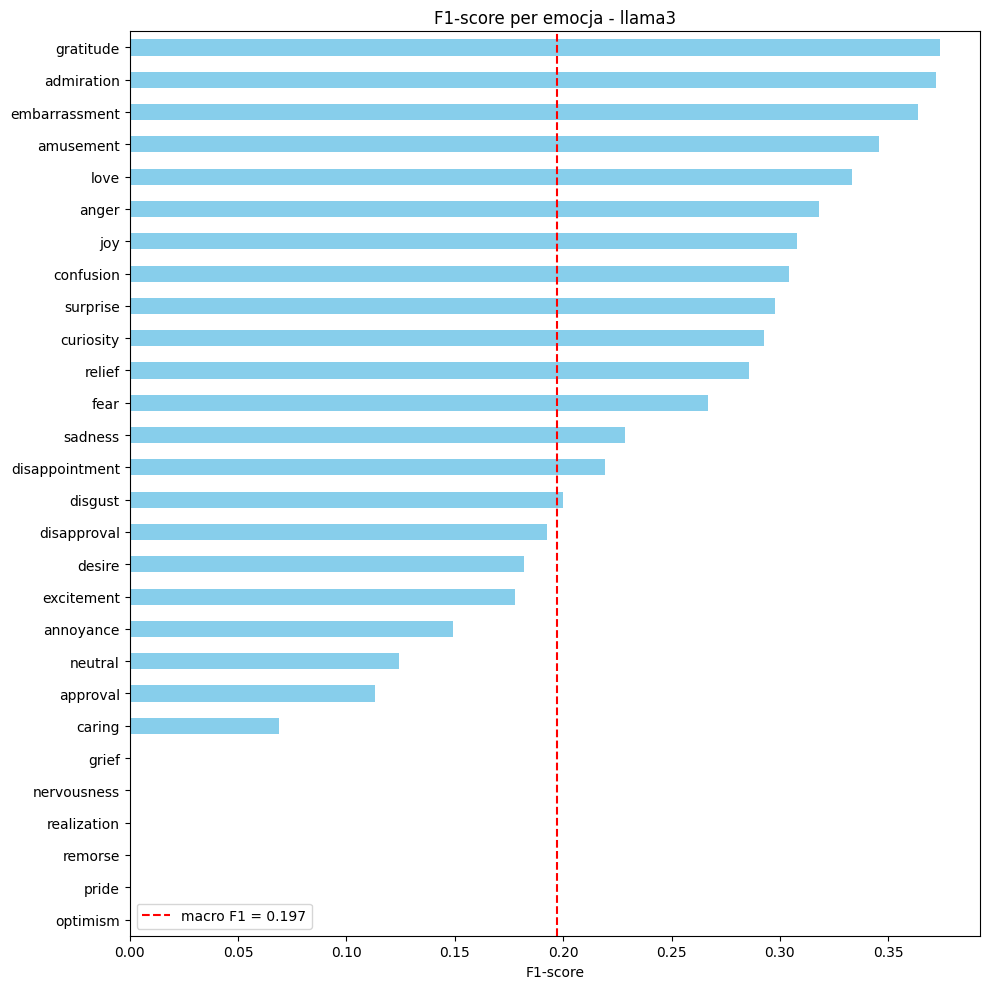

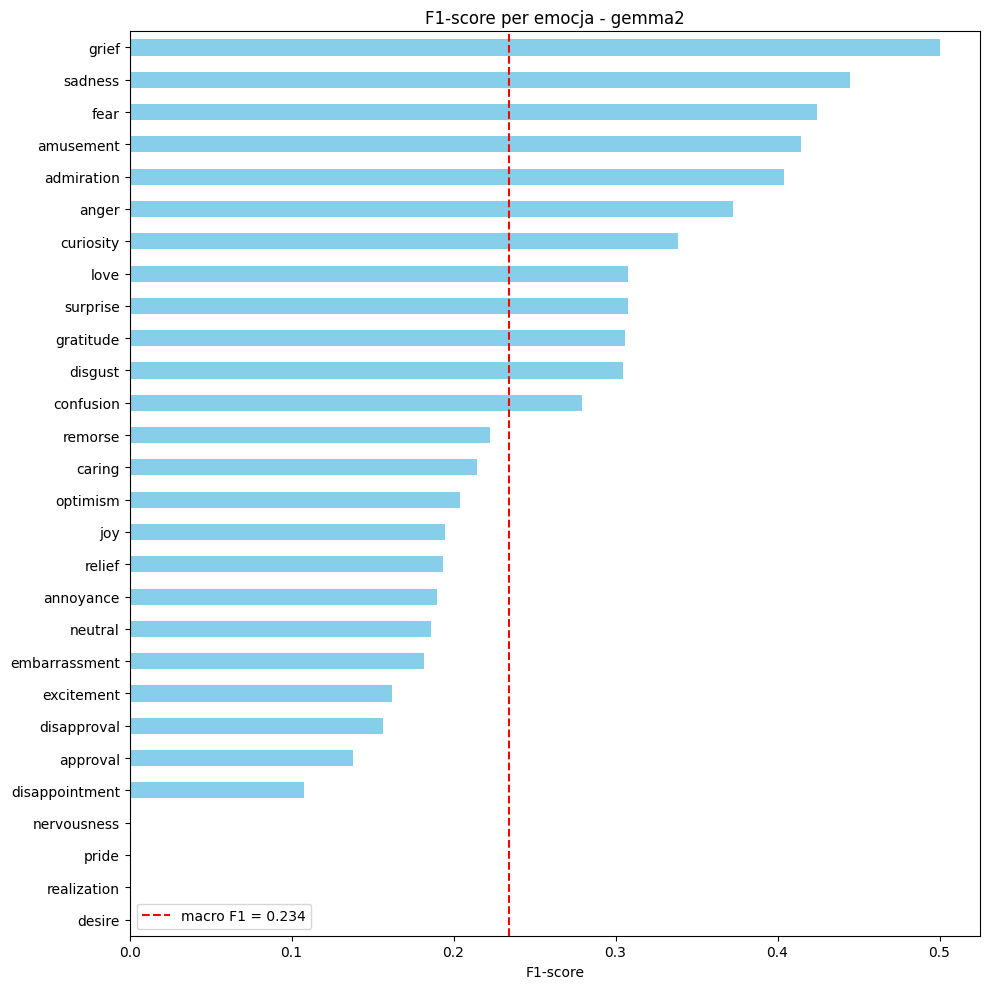

In [21]:
def plot_f1_per_class(name):
    r = results[name]
    report = classification_report(
        r["true"], r["pred"], labels=range(NUM_LABELS),
        target_names=emotions, output_dict=True, zero_division=0,
    )
    f1s = pd.Series({e: report[e]["f1-score"] for e in emotions})
    plt.figure(figsize=(10, 10))
    f1s.sort_values().plot(kind="barh", color="skyblue")
    plt.axvline(f1s.mean(), color="red", linestyle="--", label=f"macro F1 = {f1s.mean():.3f}")
    plt.title(f"F1-score per emotion - {name}")
    plt.xlabel("F1-score")
    plt.legend()
    plt.tight_layout()
    plt.show()


for name in results:
    plot_f1_per_class(name)

### Accuracy and the full classification_report

A detailed report (precision, recall, F1, support) per class for each model. `zero_division=0` prevents errors for classes with no predictions (common with rare emotions).

In [22]:
for name, r in results.items():
    print("=" * 70)
    print(f"Model: {name}  |  accuracy = {r['metrics']['accuracy']:.4f}")
    print("=" * 70)
    print(classification_report(
        r["true"], r["pred"], labels=range(NUM_LABELS),
        target_names=emotions, zero_division=0,
    ))

Model: distilbert  |  accuracy = 0.6296
                precision    recall  f1-score   support

    admiration       0.65      0.76      0.70       348
     amusement       0.77      0.89      0.82       186
         anger       0.50      0.48      0.49       131
     annoyance       0.36      0.26      0.30       194
      approval       0.51      0.36      0.42       236
        caring       0.46      0.43      0.45        86
     confusion       0.48      0.43      0.45        97
     curiosity       0.49      0.66      0.56       176
        desire       0.60      0.48      0.53        56
disappointment       0.44      0.26      0.33        88
   disapproval       0.43      0.41      0.42       195
       disgust       0.56      0.54      0.55        76
 embarrassment       0.75      0.52      0.62        23
    excitement       0.49      0.46      0.47        57
          fear       0.67      0.77      0.71        65
     gratitude       0.92      0.90      0.91       260
       

### Cohen's Kappa

Kappa measures the agreement of the predictions with the ground truth **corrected for chance agreement**. It is more demanding than accuracy under class imbalance (guessing the majority class does not inflate the score). The closer to 1.0, the better; ~0 means a random level.

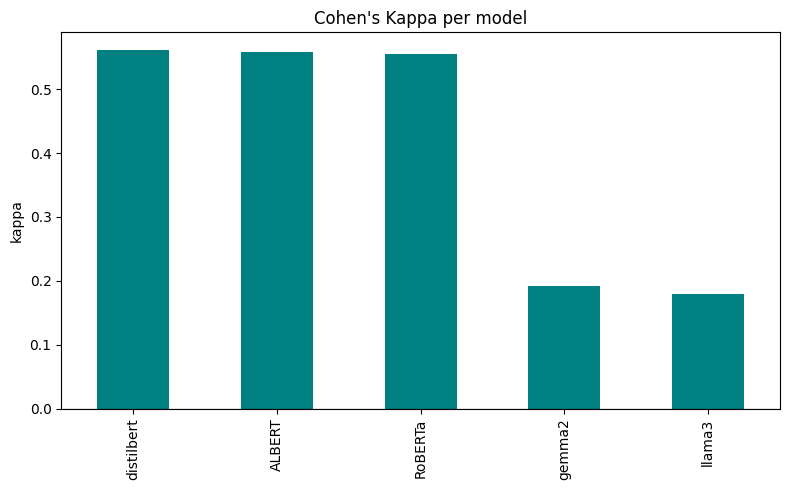

,0
distilbert,0.560998
ALBERT,0.558527
RoBERTa,0.555524
gemma2,0.192105
llama3,0.178831


In [23]:
kappa_tbl = pd.Series(
    {name: cohen_kappa_score(r["true"], r["pred"]) for name, r in results.items()}
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
kappa_tbl.plot(kind="bar", color="teal")
plt.title("Cohen's Kappa per model")
plt.ylabel("kappa")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

kappa_tbl

### Hierarchical evaluation (sentiment groups)

We map the 28 fine-grained emotions onto the 4 GoEmotions sentiment groups: **positive / negative / ambiguous / neutral**. Many confusions involve emotions that are "close to each other" (e.g. `annoyance` ↔ `anger`, `joy` ↔ `excitement`) — at a coarse level a model may be considerably better. Comparing the 28-class metrics with the 4-group ones shows how many of the errors are minor confusions within the same group.

In [24]:
def hierarchical_metrics(name):
    r = results[name]
    # Projecting the 28-class labels onto the 4 sentiment groups.
    yt = emo_id_to_sent_id[np.asarray(r["true"])]
    yp = emo_id_to_sent_id[np.asarray(r["pred"])]
    return {
        "acc_28": r["metrics"]["accuracy"],
        "f1_macro_28": r["metrics"]["f1_macro"],
        "acc_sentiment": accuracy_score(yt, yp),
        "f1_macro_sentiment": f1_score(yt, yp, average="macro", zero_division=0),
    }


hier = pd.DataFrame({name: hierarchical_metrics(name) for name in results}).T
hier.sort_values("f1_macro_sentiment", ascending=False)

,acc_28,f1_macro_28,acc_sentiment,f1_macro_sentiment
distilbert,0.629630,0.483517,0.724183,0.695318
RoBERTa,0.619826,0.522837,0.719826,0.691931
ALBERT,0.635512,0.490913,0.722004,0.689918
gemma2,0.239000,0.234058,0.481000,0.446484
llama3,0.227000,0.197026,0.484000,0.438622


### Top-k accuracy (k=3)

Whether the true emotion is among the 3 most confident predictions of the model. Emotions are sometimes ambiguous, so top-1 can be too strict. The metric requires a probability distribution - it is available only for the BERT models (for GPT it returns `None`).

In [25]:
topk_tbl = pd.DataFrame({
    name: {
        "top1_accuracy": r["metrics"]["accuracy"],
        "top3_accuracy": top_k_accuracy(r["true"], r["proba"], k=3),
    }
    for name, r in results.items()
}).T
# top3 = NaN for the GPT models (no probability distribution).
topk_tbl

,top1_accuracy,top3_accuracy
distilbert,0.629630,0.859477
RoBERTa,0.619826,0.869499
ALBERT,0.635512,0.863181
llama3,0.227000,NaN
gemma2,0.239000,NaN


### Most frequently confused pairs of emotions

A ranking of the largest off-diagonal values of the confusion matrix — it shows which emotions the model confuses most often (e.g. `approval` → `neutral`). It helps to interpret the errors as sensible (neighbouring emotions) or as random.

In [26]:
def most_confused_pairs(name, top_n=10):
    r = results[name]
    cm = confusion_matrix(r["true"], r["pred"], labels=range(NUM_LABELS))
    pairs = [
        (emotions[i], emotions[j], int(cm[i, j]))
        for i in range(NUM_LABELS)
        for j in range(NUM_LABELS)
        if i != j and cm[i, j] > 0
    ]
    df = pd.DataFrame(pairs, columns=["true", "predicted", "count"])
    return df.sort_values("count", ascending=False).head(top_n).reset_index(drop=True)


for name in results:
    print(f"--- {name}: top confused pairs (true -> predicted) ---")
    print(most_confused_pairs(name).to_string(index=False))
    print()

--- distilbert: top mylonych par (prawdziwa -> przewidziana) ---
     prawdziwa przewidziana  liczba
      approval      neutral      88
       neutral    curiosity      68
   disapproval      neutral      67
     annoyance      neutral      64
       neutral  disapproval      54
       neutral     approval      49
       neutral   admiration      45
   realization      neutral      40
disappointment      neutral      37
     curiosity      neutral      32

--- RoBERTa: top mylonych par (prawdziwa -> przewidziana) ---
  prawdziwa przewidziana  liczba
   approval      neutral      79
    neutral    curiosity      73
disapproval      neutral      64
    neutral   admiration      62
  annoyance      neutral      58
    neutral     approval      56
    neutral  disapproval      52
    neutral    annoyance      45
realization      neutral      39
    neutral       caring      33

--- ALBERT: top mylonych par (prawdziwa -> przewidziana) ---
     prawdziwa przewidziana  liczba
      approval 

### Inter-model agreement + McNemar's test

- **Pairwise Cohen's Kappa** - how much the models agree with each other (regardless of correctness). Low BERT↔GPT agreement suggests that they make different errors.
- **McNemar's test** - whether the difference in the accuracy of two models is statistically significant (p < 0.05). Computed on a common subset of examples (the first `n` of the test set, because GPT was evaluated on a subset).

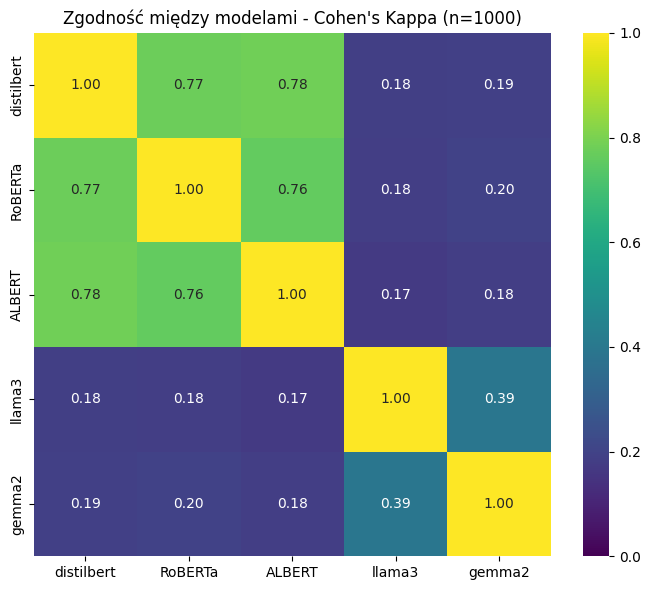

In [27]:
# Common subset: the predictions of all models on the same examples.
# BERT predicts the whole test set, GPT the first n - so we take the first common_n predictions of each model
# (the test set order is fixed, so the indices line up).
names = list(results.keys())
common_n = min(len(np.asarray(r["pred"])) for r in results.values())
aligned = {name: np.asarray(results[name]["pred"])[:common_n] for name in names}
common_true = np.asarray(results[names[0]]["true"])[:common_n]

# Matrix of pairwise Cohen's Kappa between the models.
agree = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        agree.loc[a, b] = cohen_kappa_score(aligned[a], aligned[b])

plt.figure(figsize=(7, 6))
sns.heatmap(agree.astype(float), annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1)
plt.title(f"Inter-model agreement - Cohen's Kappa (n={common_n})")
plt.tight_layout()
plt.show()

In [28]:
from statsmodels.stats.contingency_tables import mcnemar

# McNemar's test for each pair of models on the common subset.
rows = []
for a, b in combinations(names, 2):
    correct_a = aligned[a] == common_true
    correct_b = aligned[b] == common_true
    n_a_only = int(np.sum(correct_a & ~correct_b))   # only A got it right
    n_b_only = int(np.sum(~correct_a & correct_b))   # only B got it right
    table = [[0, n_a_only], [n_b_only, 0]]
    p_value = mcnemar(table, exact=False, correction=True).pvalue
    rows.append((a, b, n_a_only, n_b_only, p_value, "yes" if p_value < 0.05 else "no"))

mcnemar_df = pd.DataFrame(
    rows, columns=["model_A", "model_B", "only_A_correct", "only_B_correct", "p_value", "significant(p<0.05)"]
)
mcnemar_df

,model_A,model_B,tylko_A_trafil,tylko_B_trafil,p_value,istotne(p<0.05)
0,distilbert,RoBERTa,68,62,6.610028e-01,nie
1,distilbert,ALBERT,59,58,1.000000e+00,nie
2,distilbert,llama3,485,59,3.470423e-74,tak
3,distilbert,gemma2,480,66,6.560936e-70,tak
4,RoBERTa,ALBERT,66,71,7.325443e-01,nie
5,RoBERTa,llama3,476,56,9.602359e-74,tak
6,RoBERTa,gemma2,468,60,3.364079e-70,tak
7,ALBERT,llama3,482,57,1.631606e-74,tak
8,ALBERT,gemma2,481,68,3.282451e-69,tak
9,llama3,gemma2,81,93,4.043329e-01,nie


### Quality vs cost (latency)

An overview of quality (macro F1) against cost (prediction latency per example). The fine-tuned BERTs are small and fast, but they required training; the GPT models work zero-shot, yet they are considerably slower and heavier. The plot helps to assess what pays off in practice.

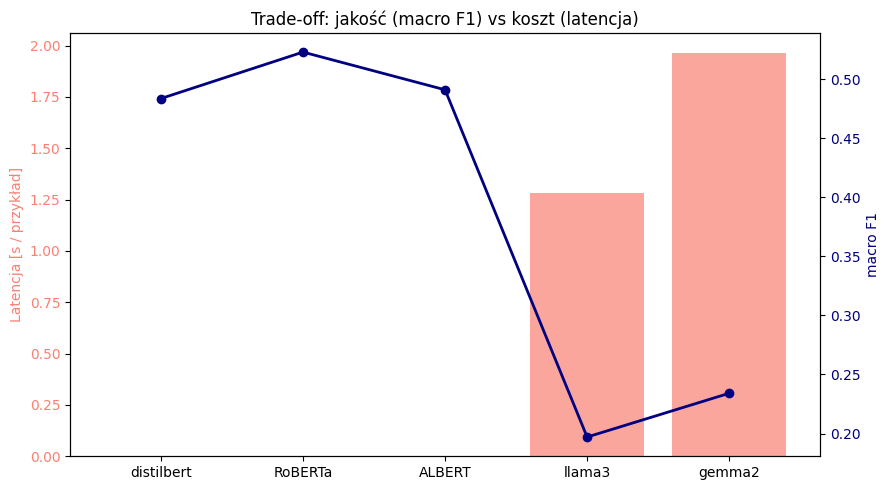

,macro_f1,latency_s/ex
RoBERTa,0.522837,0.001972
ALBERT,0.490913,0.003148
distilbert,0.483517,0.000988
gemma2,0.234058,1.964067
llama3,0.197026,1.279792


In [29]:
lat = pd.Series({name: r["extra"].get("latency_per_sample_s", np.nan) for name, r in results.items()})
f1m = pd.Series({name: r["metrics"]["f1_macro"] for name, r in results.items()})

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(lat.index, lat.values, color="salmon", alpha=0.7)
ax1.set_ylabel("Latency [s / example]", color="salmon")
ax1.tick_params(axis="y", labelcolor="salmon")

ax2 = ax1.twinx()
ax2.plot(f1m.index, f1m.values, color="navy", marker="o", linewidth=2)
ax2.set_ylabel("macro F1", color="navy")
ax2.tick_params(axis="y", labelcolor="navy")

plt.title("Trade-off: quality (macro F1) vs cost (latency)")
fig.tight_layout()
plt.show()

pd.DataFrame({"macro_f1": f1m, "latency_s/ex": lat}).sort_values("macro_f1", ascending=False)

### F1 per emotion vs class frequency

A scatter plot: the X axis = the number of training examples of a given emotion (log scale), the Y axis = the F1 of that emotion. It shows the influence of the class imbalance — whether the weak results concern mainly the rare classes. The zero-shot GPT models should be less dependent on the frequency (they were not trained on this data).

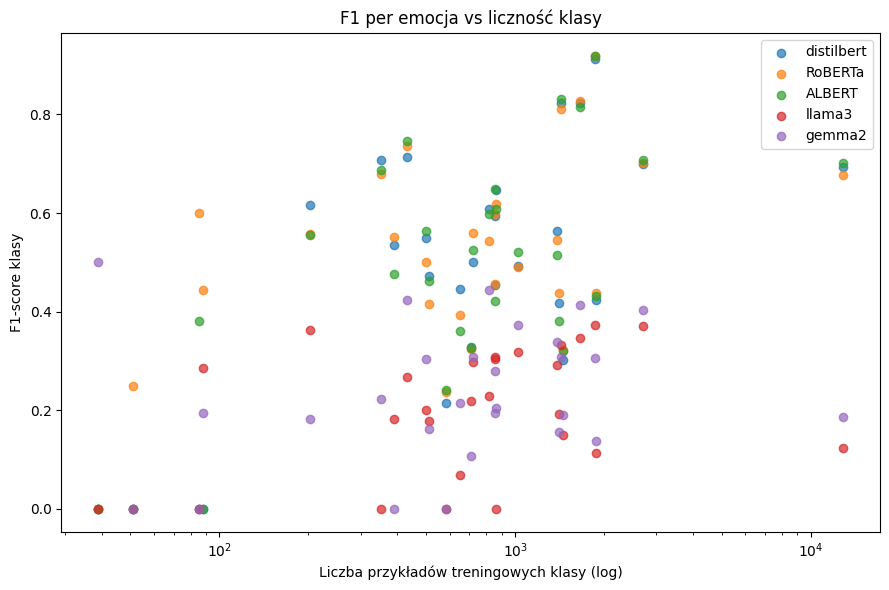

In [30]:
# The frequency of each class in the training set.
train_counts = pd.Series(np.array(dataset["train"]["label"])).value_counts()
class_counts = np.array([train_counts.get(i, 0) for i in range(NUM_LABELS)])

plt.figure(figsize=(9, 6))
for name, r in results.items():
    report = classification_report(
        r["true"], r["pred"], labels=range(NUM_LABELS),
        target_names=emotions, output_dict=True, zero_division=0,
    )
    f1s = np.array([report[e]["f1-score"] for e in emotions])
    plt.scatter(class_counts, f1s, label=name, alpha=0.7)

plt.xscale("log")
plt.xlabel("Number of training examples of the class (log)")
plt.ylabel("F1-score of the class")
plt.title("F1 per emotion vs class frequency")
plt.legend()
plt.tight_layout()
plt.show()